#scikit-learnの復習

In [1]:
#データの前処理
import numpy as np
import pandas as pd
df = pd.DataFrame(  #サンプルデータの作成
    {
        'A':[1, np.nan, 3,4,5],
        'B':[6, 7, 8, np.nan, 10],
        'C':[11, 12, 13, 14, 15]
    }
)
df

,A,B,C
0,1.0,6.0,11
1,NaN,7.0,12
2,3.0,8.0,13
3,4.0,NaN,14
4,5.0,10.0,15


In [2]:
df.isnull()   #各要素が欠損値かどうかを判別

,A,B,C
0,False,False,False
1,True,False,False
2,False,False,False
3,False,True,False
4,False,False,False


In [3]:
#欠損値の補完
from sklearn.impute import SimpleImputer #欠損値を埋めるクラス
imp = SimpleImputer(strategy='mean')
imp.fit(df)
imp.transform(df)


array([[ 1.  ,  6.  , 11.  ],
       [ 3.25,  7.  , 12.  ],
       [ 3.  ,  8.  , 13.  ],
       [ 4.  ,  7.75, 14.  ],
       [ 5.  , 10.  , 15.  ]])

In [ ]:
#カテゴリ変数のエンコーディング 血液型などの限られた値において、それぞれどれに該当しているかを示す変数
df = pd.DataFrame(
    {
        'A': [1, 2, 3, 4, 5],
        'B': ['a', 'b', 'a', 'b', 'c']
    }
)
df   

,A,B
0,1,a
1,2,b
2,3,a
3,4,b
4,5,c


In [ ]:
#a,b,cがカテゴリ変数　これらをコンピューターが処理しやすいように変数に変換する
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
#ラベルのエンコーディング
le.fit_transform(df.loc[:,'B'])    #a=0,b=1,c=2に変換

array([0, 1, 0, 1, 2])

In [7]:
#one-hotエンコーディング
#カテゴリ変数の数だけ列を増やし、該当する値の列にのみ1を入力する変換方法
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
df_ohe = df.copy() #dfをコピー
le = LabelEncoder()
df_ohe.loc[:,'B'] = le.fit_transform(df_ohe.loc[:,'B']) #ひとつ前のセルと同じ処理を代入
#onehotエンコーダーのインスタンス化
#ColumnTransformerは列ごとに異なる変換をまとめて適応するクラス
ohe = ColumnTransformer([('OneHotEncoder',           #名前　メモみたいなもん
                         OneHotEncoder(),[1])],      #どの列をどんな変換するか
                         remainder='passthrough')    #その他の列の処理
df_ohe = ohe.fit_transform(df_ohe)
df_ohe

array([[1., 0., 0., 1.],
       [0., 1., 0., 2.],
       [1., 0., 0., 3.],
       [0., 1., 0., 4.],
       [0., 0., 1., 5.]])

In [8]:
#正規化 標準化 データの平均が０、標準偏差が１になるように変換する処理
import pandas as pd
df = pd.DataFrame(
    {
        'A':[1, 2, 3, 4, 5],
        'B':[100, 200, 400, 500,800]
    }
)
df

,A,B
0,1,100
1,2,200
2,3,400
3,4,500
4,5,800


In [9]:
from sklearn.preprocessing import StandardScaler
#正規化のインスタンスを生成
stdsc = StandardScaler()
stdsc.fit_transform(df)

array([[-1.41421356, -1.22474487],
       [-0.70710678, -0.81649658],
       [ 0.        ,  0.        ],
       [ 0.70710678,  0.40824829],
       [ 1.41421356,  1.63299316]])

In [ ]:
#分類 データのクラスを予測して分けるタスク　
#まずデータセットの準備
from sklearn.datasets import load_iris
#irisデータセットを読み込む
iris = load_iris()
x, y = iris.data, iris.target
print('x:')             #左からがくの長さ、がくの幅、花弁の長さ、花弁の幅を表す（説明変数）
print(x[:5,:])
print('y:')             #アヤメの種類を表す目的変数 0,1,2
print(y[:5])

x:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
y:
[0 0 0 0 0]


In [13]:
from sklearn.model_selection import train_test_split
#学習データとテストデータに分割
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=123)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(105, 4)
(45, 4)
(105,)
(45,)


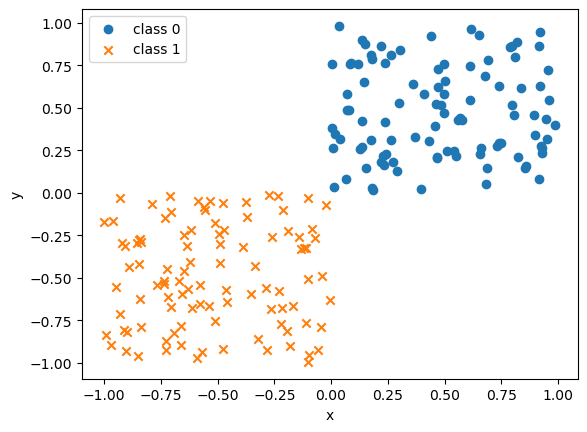

In [20]:
# サポートベクタマシン　分類モデルの一つ
#二次元に二つのクラスのデータがあるとき、これらを直線で分離する際、この直線とそれに最も近い各クラスのデータ間の距離が最も大きくなるように直線を引くモデル
#ふたつのクラスに属する二次元データを作成
import matplotlib.pyplot as plt
rng = np.random.default_rng(123)
#0~1の一様分布100点をサンプリング
x0 = rng.uniform(size=(100,2))
y0 = np.repeat(0,100)  #クラス０のラベルを１００個生成
#-1~0の一様分布100点
x1 = rng.uniform(-1.0, 0.0, size=(100,2))
y1 = np.repeat(1,100)  #クラス１のラベル

fig, ax = plt.subplots()
ax.scatter(x0[:,0], x0[:,1],
           marker='o', label='class 0')
ax.scatter(x1[:,0], x1[:,1],
           marker='x', label='class 1')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
plt.show()



In [24]:
#学習、および決定境界、マージン、サポートベクタを可視化する関数
from sklearn.svm import SVC
def plot_boundary_margin_sv(x0, y0, x1, y1, kernel, C,
                            xmin=-1, xmax=1, ymin=-1, ymax=1):
    #サポートベクタマシンのインスタンス化
    svc = SVC(kernel=kernel, C=C)
    #学習
    svc.fit(np.vstack((x0, x1)), np.hstack((y0, y1)))

    fig, ax = plt.subplots()
    ax.scatter(x0[:, 0], x0[:, 1], marker='o', label='class 0')
    ax.scatter(x1[:, 0], x1[:, 1], marker='x', label='class 1')
    #決定境界とマージンをプロット
    xx, yy = np.meshgrid(np.linspace(xmin, xmax, 100),
                         np.linspace(ymin, ymax, 100))
    xy = np.vstack([xx.ravel(), yy.ravel()]).T
    p = svc.decision_function(xy).reshape((100, 100))
    ax.contour(xx, yy, p, colors='k', levels=[-1,0,1],              #等高線の高さを決定
               alpha=0.5, linestyles=['--', '-', '--'])
    #サポートベクタをプロット
    ax.scatter(svc.support_vectors_[:, 0], svc.support_vectors_[:,1],
               s=250, facecolors='none', edgecolors='black')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(loc='best')
    plt.show()

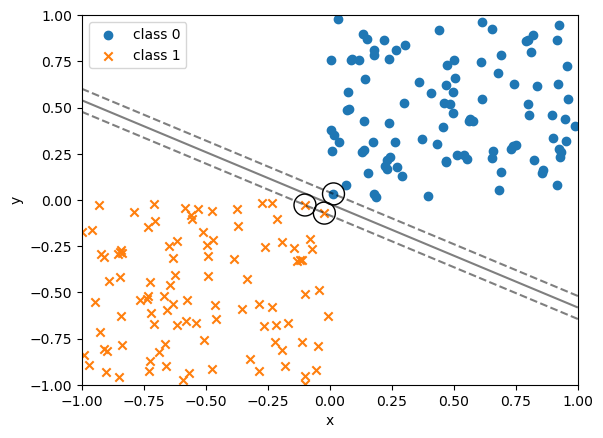

In [25]:
plot_boundary_margin_sv(x0, y0, x1, y1, kernel='linear', C=1e6)

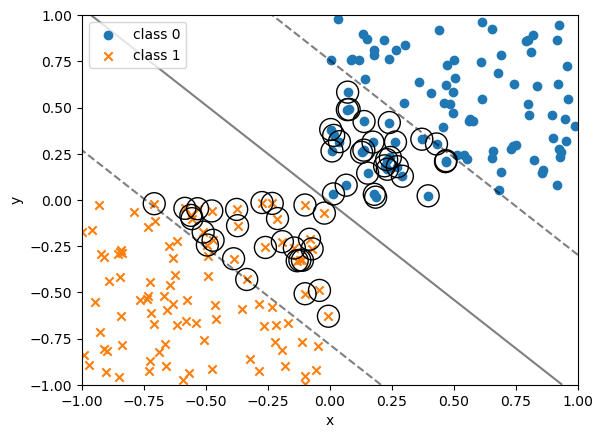

In [26]:
#Cの大きさを変える
plot_boundary_margin_sv(x0, y0, x1, y1, kernel='linear', C=0.1)

Cはどれだけマージンを広くとるかを表す
Cが大きい→誤分類を許さない　過学習しやすい
Cが小さい→多少の誤差を許す